In [1]:
import pandas as pd

In [4]:
df=pd.read_csv("Coca_Cola_historical_data.csv")

In [5]:
df.head()

,Date,Open,High,Low,Close,Volume,ticker,name
0,1962-01-02 00:00:00-05:00,0.045368,0.046604,0.045368,0.045368,806400,KO,The Coca-Cola Company (KO) Historical Data
1,1962-01-03 00:00:00-05:00,0.044695,0.044695,0.043684,0.044358,1574400,KO,The Coca-Cola Company (KO) Historical Data
2,1962-01-04 00:00:00-05:00,0.044470,0.045032,0.044470,0.044695,844800,KO,The Coca-Cola Company (KO) Historical Data
3,1962-01-05 00:00:00-05:00,0.044695,0.045256,0.043572,0.043684,1420800,KO,The Coca-Cola Company (KO) Historical Data
4,1962-01-08 00:00:00-05:00,0.043347,0.043347,0.042392,0.043235,2035200,KO,The Coca-Cola Company (KO) Historical Data


In [6]:
df.describe()

,Open,High,Low,Close,Volume
count,16066.000000,16066.000000,16066.000000,16066.000000,1.606600e+04
mean,13.147436,13.247414,13.044540,13.149752,9.395165e+06
std,17.173774,17.290152,17.051949,17.174510,7.960818e+06
min,0.033701,0.033815,0.031648,0.033587,7.680000e+04
25%,0.221348,0.223215,0.219830,0.221370,3.175800e+06
50%,4.808939,4.847521,4.765701,4.809202,8.187800e+06
75%,17.625486,17.768250,17.505767,17.628664,1.339160e+07
max,72.307406,73.292796,71.854138,72.819817,1.241690e+08


In [7]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
ticker    0
name      0
dtype: int64

In [9]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)


In [10]:
df = df.sort_values('Date')

In [11]:
df = df[(df['Low'] <= df['Open']) & (df['Low'] <= df['Close']) &
        (df['High'] >= df['Open']) & (df['High'] >= df['Close'])]

In [12]:
print(df.describe())

               Open          High           Low         Close        Volume
count  16023.000000  16023.000000  16023.000000  16023.000000  1.602300e+04
mean      13.165165     13.265290     13.062138     13.167470  9.398278e+06
std       17.183357     17.299796     17.061493     17.184104  7.964917e+06
min        0.033701      0.033815      0.031648      0.033587  7.680000e+04
25%        0.221370      0.223346      0.219973      0.221546  3.171600e+06
50%        4.813411      4.850780      4.776166      4.815038  8.189600e+06
75%       17.637731     17.774872     17.514766     17.642036  1.339790e+07
max       72.307406     73.292796     71.854138     72.819817  1.241690e+08


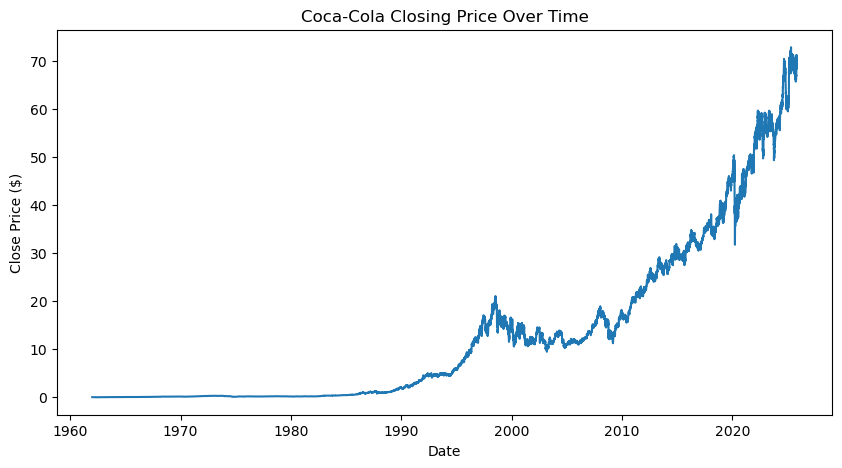

In [13]:
import matplotlib.pyplot as plt

# Plot closing price over time
plt.figure(figsize=(10,5))
plt.plot(df['Date'], df['Close'])
plt.title('Coca-Cola Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price ($)')
plt.show()


In [15]:
avg_return = round(df['Close'].pct_change().mean() * 100, 2)
volatility = round(df['Close'].pct_change().std() * 100, 2)

print("Average daily return:", avg_return, "%")
print("Volatility:", volatility, "%")


Average daily return: 0.06 %
Volatility: 1.44 %


In [16]:
df['Daily_Change'] = df['Close'] - df['Open']
df['Volatility'] = df['High'] - df['Low']
df['7_Day_MA'] = df['Close'].rolling(7).mean()
df['30_Day_MA'] = df['Close'].rolling(30).mean()


In [18]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df['Days'] = (df['Date'] - df['Date'].min()).dt.days

model = LinearRegression()
model.fit(df[['Days']], df['Close'])

# Predict next 30 days
future_days = pd.DataFrame({'Days': np.arange(df['Days'].max()+1, df['Days'].max()+31)})
predicted = model.predict(future_days)


In [19]:
corr = df[['Open','High','Low','Close','Volume']].corr()
print(corr)


            Open      High       Low     Close    Volume
Open    1.000000  0.999964  0.999958  0.999925  0.438894
High    0.999964  1.000000  0.999944  0.999963  0.440095
Low     0.999958  0.999944  1.000000  0.999964  0.437278
Close   0.999925  0.999963  0.999964  1.000000  0.438602
Volume  0.438894  0.440095  0.437278  0.438602  1.000000


<Axes: >

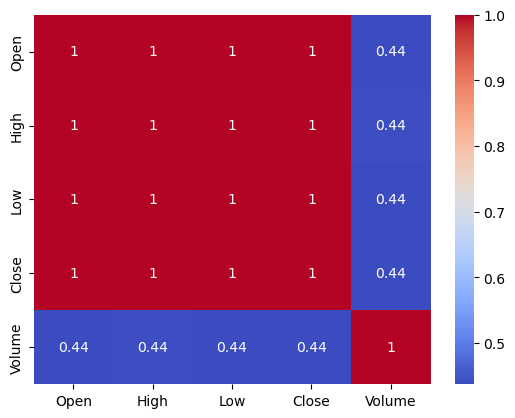

In [20]:
import seaborn as sns

sns.heatmap(df[['Open','High','Low','Close','Volume']].corr(), annot=True, cmap='coolwarm')


In [23]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="rabin8866",      # ← your MySQL password
    database="rabin"   # you can change this to another DB if needed
)
cursor = conn.cursor()

# --- Step 3: Create the table ---
cursor.execute("""
CREATE TABLE IF NOT EXISTS coca_cola_data (
    id INT AUTO_INCREMENT PRIMARY KEY,
    Date DATE,
    Open FLOAT,
    High FLOAT,
    Low FLOAT,
    Close FLOAT,
    Volume BIGINT,
    ticker VARCHAR(20),
    name VARCHAR(50)
);
""")

# --- Step 4: Insert data ---
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO coca_cola_data (Date, Open, High, Low, Close, Volume, ticker, name)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
    """, (
        row['Date'], 
        row['Open'], 
        row['High'], 
        row['Low'], 
        row['Close'], 
        row['Volume'], 
        row['ticker'], 
        row['name']
    ))

conn.commit()
print("✅ Data successfully inserted into MySQL table 'coca_cola_data'!")

# --- Step 5: Verify insertion ---
cursor.execute("SELECT COUNT(*) FROM coca_cola_data;")
count = cursor.fetchone()[0]
print(f"📊 Total rows inserted: {count}")

✅ Data successfully inserted into MySQL table 'coca_cola_data'!
📊 Total rows inserted: 16023
